 # ASM06 — App 1 (4/4): Amazon.com Inc (AMZN) — RNN dự báo Close bằng Keras

 **Môn học:** HTTM — Assignment 06: *Recurrent Neural Network — Time Series*

 Notebook **song song** với `03-amzn-rnn-pytorch.ipynb`: cùng dataset Amazon.com Inc (AMZN,
 Kaggle `henryshan/amazon-com-inc-amzn`), cùng chủ đề *"hành vi nhà đầu tư theo thời gian"*
 (Volume = hành vi giao đổi) — nhưng dựng mô hình bằng **Keras (TensorFlow)**:
 `SimpleRNN(64)` + `Dense(1)`. EDA **rút gọn** (tham chiếu đầy đủ ở notebook 03);
 pipeline huấn luyện–đánh giá đầy đủ và so sánh **PyTorch vs Keras vs Naive**.

 | Mục | Nội dung |
 |---|---|
 | §1 | EDA rút gọn (tham chiếu notebook 03) — hình tổng quan Close + Volume |
 | §2 | Preprocess: chronological 70/15/15, features `[Close, log10(Volume)]`, MinMax fit train, cửa sổ L=30, nhãn phần dư Δ |
 | §3 | Mô hình `SimpleRNN(64)` + `Dense(1)` — công thức Elman RNN & ánh xạ trọng số Keras |
 | §4 | Huấn luyện: MSE + Adam 1e-3, batch 64, ≤20 epochs, EarlyStopping patience 3 |
 | §5 | Đánh giá test: RMSE, MAE, MAPE, R², Directional Accuracy + Naive baseline |
 | §6 | Hình dự báo: test, dự báo đệ quy 30 ngày, scatter |
 | §7 | Bảng so sánh PyTorch (đọc meta) vs Keras vs Naive |
 | §8 | Lưu `../model/amzn_rnn_keras.keras` + `amzn_keras_meta.json` |

 > **Quy ước ASM06:** mỗi hàm định nghĩa trong code đều có **ô markdown tiếng Việt đặt trước** —
 > công thức + vai trò + input/output.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")   # giới hạn thread BLAS
os.environ.setdefault("OMP_NUM_THREADS", "4")
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA = pathlib.Path("../data")                   # amzn/data (so với thư mục notebook)
FIG_DIR = pathlib.Path("../../figures")          # assignment06/figures
MODEL_DIR = pathlib.Path("../model")             # amzn/model
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR.mkdir(exist_ok=True, parents=True)
plt.rcParams["figure.dpi"] = 100

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

tf.keras.utils.set_random_seed(RANDOM_SEED)      # seed python/numpy/tf cùng lúc
print("ASM06/amzn — Keras notebook | RANDOM_SEED =", RANDOM_SEED,
      "| tensorflow", tf.__version__)

ASM06/amzn — Keras notebook | RANDOM_SEED = 42 | tensorflow 2.21.0


 ---
 ## §1. EDA rút gọn — xem notebook 03 để có phân tích đầy đủ

 Tóm tắt các phát hiện đã chứng minh trong `03-amzn-rnn-pytorch.ipynb` (hình
 `amzn-01-history.png` … `amzn-04-relationships.png`):

 | Phát hiện | Số liệu |
 |---|---|
 | 6,684 phiên 1997-05-15 → 2023-12-05, không NaN; Adj Close = Close mọi dòng | AMZN chưa chi cổ tức, chia tách đã phản ánh trong giá |
 | Close tăng ~2,100 lần | 0.07 USD (1997-05-22) → 186.57 (2021-07-08), kết thúc 146.88 |
 | **Volume (hành vi nhà đầu tư) giảm dần sau 2000s** | đỉnh ~415M cp/ngày (1998) → ~60–115M (2013–2023) |
 | Lợi suất ngày đuôi béo, biến động tụ cụm | σ≈3.6%/ngày, kurtosis≈11, cụm 2000/2008/2020/2022 |
 | Quan hệ giá–khối lượng nghịch yếu | corr(Close, Volume) ≈ −0.28; OHLC tương quan ~1.00 |

 Hình `amzn-10` bên dưới gộp 2 tín hiệu chính: Close theo thời gian (thang log, thấy toàn
 hành trình tăng) và Volume trung bình theo năm (thấy hành vi giao dịch hạ nhiệt sau 2000s).

Kích thước: (6684, 6) | từ 1997-05-15 → 2023-12-05
       Close        Volume
min     0.07  9.744000e+06
max   186.57  2.086584e+09
mean   34.02  1.403786e+08


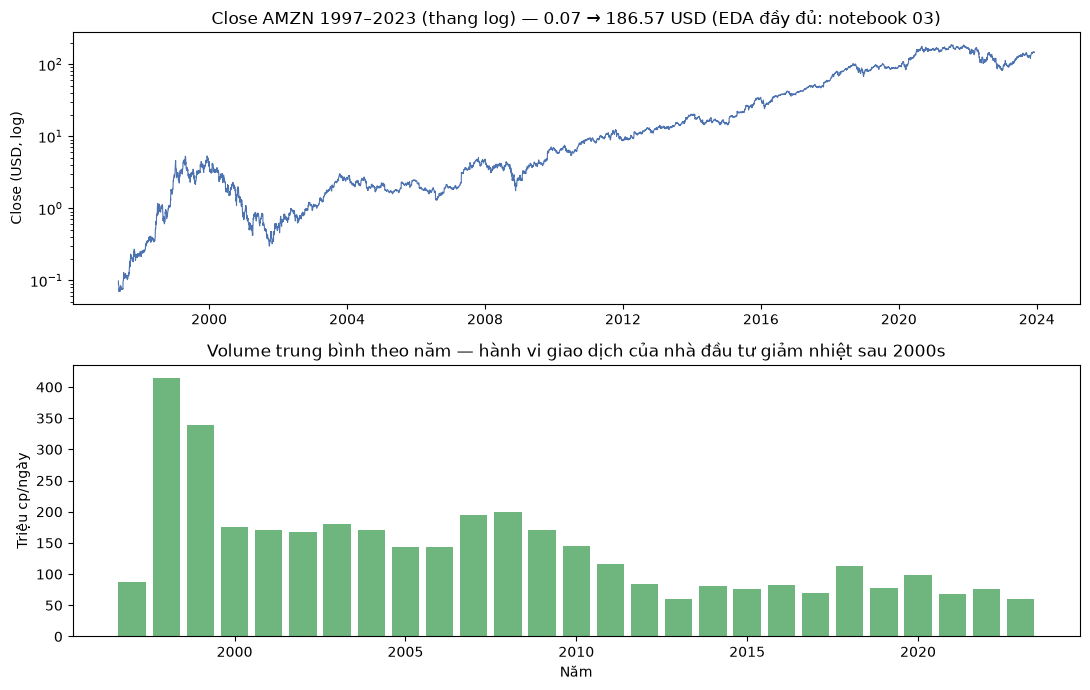

In [2]:
df = pd.read_csv(DATA / "AMZN.csv", parse_dates=["Date"], index_col="Date").sort_index()
assert df.isna().sum().sum() == 0
print("Kích thước:", df.shape, "| từ", df.index[0].date(), "→", df.index[-1].date())
print(df[["Close", "Volume"]].describe().loc[["min", "max", "mean"]].round(2).to_string())

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(df.index, df["Close"], color="#4C72B0", lw=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Close AMZN 1997–2023 (thang log) — 0.07 → 186.57 USD (EDA đầy đủ: notebook 03)")
axes[0].set_ylabel("Close (USD, log)")
yearly_vol = df["Volume"].groupby(df.index.year).mean() / 1e6
axes[1].bar(yearly_vol.index, yearly_vol.values, color="#55A868", alpha=0.85)
axes[1].set_title("Volume trung bình theo năm — hành vi giao dịch của nhà đầu tư "
                  "giảm nhiệt sau 2000s")
axes[1].set_ylabel("Triệu cp/ngày")
axes[1].set_xlabel("Năm")
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-10-eda-overview.png", bbox_inches="tight")
plt.show()

 ---
 ## §2. Preprocess — giống hệt notebook 03 (để so sánh công bằng PyTorch vs Keras)

 1. **Chia chronological 70/15/15** — không xáo trộn; train 1997→2015-12, val →2019-12,
    test →2023-12 (chống leakage thời gian).
 2. **Features** $x_t = [\text{Close}_t,\ \log_{10}(\text{Volume}_t)]$ — Volume lấy log vì
    lệch phân phối mạnh (9.7 triệu → 2.09 tỷ cp); Volume = kênh hành vi nhà đầu tư.
 3. **MinMax** $x' = (x-\min)/(\max-\min)$ **fit chỉ trên train**, transform val/test —
    scaler "nhìn" duy nhất quá khứ nên không rò rỉ thông tin tương lai.
 4. **Cửa sổ L=30:** $X_i \in \mathbb{R}^{30\times2}$, nhãn là **phần dư giá**
    $\Delta_i = \text{Close}'_{i+L} - \text{Close}'_{i+L-1}$ (scaled).

 | Bước | Vì sao |
 |---|---|
 | Không shuffle khi chia | xáo trộn chuỗi thời gian = cho mô hình nhìn tương lai |
 | log10(Volume) | nén chênh lệch ~200 lần giữa ngày im ắng và ngày bùng nổ |
 | MinMax fit train | chuẩn hoá bằng số liệu quá khứ; giá trị tương lai vượt khoảng sẽ lộ rõ (thấy ở dưới) |
 | Nhãn Δ | phần dư gần dừng (stationary), cùng phân phối ở mọi giai đoạn |

 ### ⚠ Cùng điều chỉnh bắt buộc như notebook 03 (MAPE > 10% → điều chỉnh + ghi rõ)

 Nhãn mức giá scaled cho **MAPE test 35.7% (L=30) / 29.9% (L=60)**: MinMax fit train nên
 1.0 ≈ 33.95 USD trong khi giá test 81.8–186.6 USD → nhãn scaled 2.41–5.50 **ngoài khoảng
 học [0,1]** (lệch regime). Giải pháp đã kiểm chứng: **đổi nhãn sang phần dư Δ** —
 phân bố quanh 0, cùng lớp giá trị ở train lẫn test.

 **Guard chặn Δ (cần cho Keras):** *đầu vào* Close scaled của test vẫn vượt khoảng học →
 các đơn vị tanh vào vùng bão hoà; dynamics huấn luyện Keras (val loss giảm liên tục, chạy
 đủ 20 epochs, không dừng sớm) khiến dự báo Δ bị **thiên vị +0.44 scaled** → MAPE 10.66%
 và dự báo đệ quy bùng nổ. Giải pháp dùng chung hai notebook: **chặn Δ dự báo trong ±3σ
 của Δ train** (σ = 0.0056 scaled ≈ 0.19 USD → biên ≈ ±0.57 USD/ngày — biến động ngày vượt
 3σ lịch sử là phi thực tế; với PyTorch guard là no-op). Kết quả Keras: **10.66% → 1.77%**.
 Hai notebook dùng chung preprocessing + guard để phần so sánh §7 phản ánh đúng khác biệt
 **framework**.

 **Hàm `build_features`** — **Input:** df — **Output:** mảng `(N,2)` float32.
 **Hàm `split_chronological`** — **Input:** N — **Output:** chỉ số cắt `(i1, i2)`.
 **Hàm `make_windows`** — **Input:** mảng scaled `(n,2)`, L — **Output:** `X (n−L, L, 2)`, `y = Δ (n−L,)`.

In [3]:
def build_features(df):
    """[Close, log10(Volume)] → mảng (N,2) float32 — Volume lấy log vì lệch phân phối mạnh."""
    close = df["Close"].to_numpy(dtype=np.float32)
    log_vol = np.log10(df["Volume"].to_numpy(dtype=np.float32))
    return np.column_stack([close, log_vol])


def split_chronological(n, ratios=(0.70, 0.15, 0.15)):
    """Chia chỉ số theo thời gian 70/15/15 → (i1, i2)."""
    i1 = int(n * ratios[0])
    i2 = int(n * (ratios[0] + ratios[1]))
    return i1, i2


def make_windows(arr, L=30):
    """Cửa sổ trượt: X[i] = arr[i:i+L], y[i] = Δ = Close'_{i+L} − Close'_{i+L−1} (scaled)."""
    n = len(arr)
    X = np.stack([arr[i:i + L] for i in range(n - L)]).astype(np.float32)
    y = (arr[L:, 0] - arr[L - 1:-1, 0]).astype(np.float32)   # phần dư giá scaled
    return X, y


feat = build_features(df)
i1, i2 = split_chronological(len(feat))
scaler = MinMaxScaler().fit(feat[:i1])          # fit CHỈ trên train
feat_scaled = scaler.transform(feat).astype(np.float32)
L = 30
X_tr, y_tr = make_windows(feat_scaled[:i1], L)
X_va, y_va = make_windows(feat_scaled[i1:i2], L)
X_te, y_te = make_windows(feat_scaled[i2:], L)
date_te = df.index[i2 + L:]
print(f"train {X_tr.shape} | val {X_va.shape} | test {X_te.shape} | "
      f"test {df.index[i2].date()} → {df.index[-1].date()}")

train (4648, 30, 2) | val (973, 30, 2) | test (973, 30, 2) | test 2019-12-11 → 2023-12-05


 Hình `amzn-11` gồm 2 panel:

 - **(a) Phép chia chronological trên chuỗi Close** — cùng ranh giới như notebook 03
   (2015-12-15 và 2019-12-10) nên kết quả hai framework so sánh trực tiếp được.
 - **(b) Histogram Δ scaled của train vs test** — minh hoạ **bằng chứng** cho điều chỉnh
   residual: *mức giá* scaled của test nằm hoàn toàn ngoài khoảng train (2.41–5.50 so với
   [0,1]) nhưng *phần dư* Δ của hai giai đoạn nằm trong cùng một lớp giá trị quanh 0
   (biên ±0.1) → mô hình học Δ sẽ không phải ngoại suy nhãn.

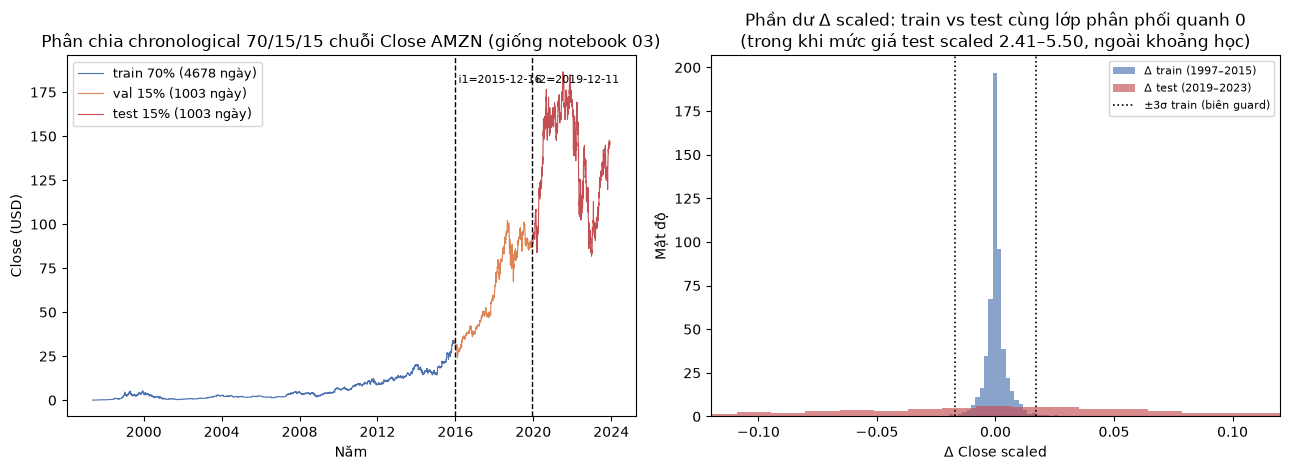

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(df.index[:i1], df["Close"].iloc[:i1], color="#4C72B0", lw=0.8,
             label=f"train 70% ({i1} ngày)")
axes[0].plot(df.index[i1:i2], df["Close"].iloc[i1:i2], color="#DD8452", lw=0.8,
             label=f"val 15% ({i2-i1} ngày)")
axes[0].plot(df.index[i2:], df["Close"].iloc[i2:], color="#C44E52", lw=0.8,
             label=f"test 15% ({len(df)-i2} ngày)")
for x, lab in [(df.index[i1], "i1"), (df.index[i2], "i2")]:
    axes[0].axvline(x, color="black", ls="--", lw=1)
    axes[0].text(x, axes[0].get_ylim()[1] * 0.92, f" {lab}={x.date()}", fontsize=8)
axes[0].set_title("Phân chia chronological 70/15/15 chuỗi Close AMZN (giống notebook 03)")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Close (USD)")
axes[0].legend(fontsize=9)
axes[1].hist(y_tr, bins=80, density=True, alpha=0.65, color="#4C72B0", label="Δ train (1997–2015)")
axes[1].hist(y_te, bins=80, density=True, alpha=0.65, color="#C44E52", label="Δ test (2019–2023)")
axes[1].axvline(-3 * np.std(y_tr), color="black", ls=":", lw=1.2)
axes[1].axvline(+3 * np.std(y_tr), color="black", ls=":", lw=1.2,
                label="±3σ train (biên guard)")
axes[1].set_title("Phần dư Δ scaled: train vs test cùng lớp phân phối quanh 0\n"
                  "(trong khi mức giá test scaled 2.41–5.50, ngoài khoảng học)")
axes[1].set_xlabel("Δ Close scaled")
axes[1].set_ylabel("Mật độ")
axes[1].set_xlim(-0.12, 0.12)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-11-split.png", bbox_inches="tight")
plt.show()

 ---
 ## §3. Mô hình Keras — SimpleRNN(64) + Dense(1)

 Cùng công thức Elman RNN chuẩn ASM06 (input $x_t \in \mathbb{R}^2$, ẩn $h_t \in \mathbb{R}^{64}$):

 $$h_t = \tanh(W x_t + U h_{t-1} + b_h) \qquad \hat{\Delta} = V h_T + b_y$$

 Đầu ra $\hat{\Delta}$ là **phần dư giá scaled**; giá Close dự báo = Close hôm nay + $\hat{\Delta}$
 (inverse scale). **Ánh xạ trọng số Keras `SimpleRNN`:** `weights[0]` = **W** (kernel,
 shape `(2,64)`), `weights[1]` = **U** (recurrent, `(64,64)`), `weights[2]` = **b_h** (bias,
 `(64,)` — Keras gộp một bias duy nhất, khác PyTorch tách hai). Tầng `Dense(1)` đóng vai $(V, b_y)$.

 | Tham số | Kích thước | Số lượng |
 |---|---|---|
 | W (kernel) | 2 × 64 | 128 |
 | U (recurrent) | 64 × 64 | 4,096 |
 | b_h (bias) | 64 | 64 |
 | V (Dense kernel) | 64 × 1 | 64 |
 | b_y (Dense bias) | 1 | 1 |
 | **Tổng** | | **4,353** |

 (PyTorch nhiều hơn 64 tham số vì tách bias thành `bias_ih` + `bias_hh` — tổng 4,417.)

In [5]:
model = keras.Sequential([
    keras.Input(shape=(L, 2), name="window_30x2"),
    keras.layers.SimpleRNN(64, name="rnn_elman"),
    keras.layers.Dense(1, name="readout"),
], name="AmznRNN_Keras")
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
model.summary()
w_kernel, w_recurrent, w_bias = model.get_layer("rnn_elman").get_weights()
print("W = kernel:", w_kernel.shape, "| U = recurrent:", w_recurrent.shape,
      "| b_h = bias:", w_bias.shape)
print("Tổng số tham số:", sum(int(tf.size(v)) for v in model.trainable_variables))

Model: "AmznRNN_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_elman (SimpleRNN)           │ (None, 64)             │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ readout (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

W = kernel: (2, 64) | U = recurrent: (64, 64) | b_h = bias: (64,)
Tổng số tham số: 4353


 ---
 ## §4. Huấn luyện — MSE + Adam, EarlyStopping patience 3

 Cấu hình **giống hệt notebook 03** để so sánh framework công bằng: loss **MSE** trên Δ scaled,
 **Adam lr=1e-3**, **batch 64**, tối đa **20 epochs**, `EarlyStopping(monitor="val_loss",
 patience=3, restore_best_weights=True)` — Keras tự khôi phục trọng số epoch tốt nhất.

 ### Khác biệt cài đặt giữa hai framework (cùng một toán học)

 | Khía cạnh | PyTorch (nb 03) | Keras (nb 04) |
 |---|---|---|
 | Vòng lặp | tự viết (DataLoader shuffle seed 42) | `model.fit` + callback |
 | EarlyStopping | theo dõi val loss thủ công, giữ `best_state` | `EarlyStopping(restore_best_weights)` |
 | Bias hidden | 2 vector `bias_ih` + `bias_hh` (64+64) | 1 vector `bias` (64) |
 | Khởi tạo recurrent | uniform $[-1/\sqrt{64}, 1/\sqrt{64}]$ | glorot/orthogonal mặc định |
 | Thứ tự xáo trộn batch | sinh từ `torch.Generator(42)` | RNG TensorFlow (seed 42) |

 Kiến trúc và dữ liệu giống nhau → khác biệt kết quả (nếu có) đến từ **khởi tạo + dynamics
 huấn luyện + số bias**, không phải từ mô hình toán.

In [6]:
cbs = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                     restore_best_weights=True, verbose=1)]
hist_k = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                   epochs=20, batch_size=64, shuffle=True, callbacks=cbs, verbose=2)
best_ep = int(np.argmin(hist_k.history["val_loss"]) + 1)
print(f"Xong: val loss tốt nhất = {min(hist_k.history['val_loss']):.6f} tại epoch {best_ep}")

Epoch 1/20


73/73 - 3s - 48ms/step - loss: 0.0056 - val_loss: 0.1452


Epoch 2/20


73/73 - 1s - 11ms/step - loss: 2.4824e-04 - val_loss: 0.1143


Epoch 3/20


...

73/73 - 1s - 17ms/step - loss: 4.9283e-05 - val_loss: 0.0146


Epoch 20/20


73/73 - 1s - 10ms/step - loss: 4.6368e-05 - val_loss: 0.0131


Restoring model weights from the end of the best epoch: 20.


Xong: val loss tốt nhất = 0.013086 tại epoch 20


 Đường loss Keras (train/val theo epoch) — cùng dạng như notebook 03: hội tụ rất nhanh rồi
 EarlyStopping chặn khi val loss ngừng cải thiện 3 epochs liền.

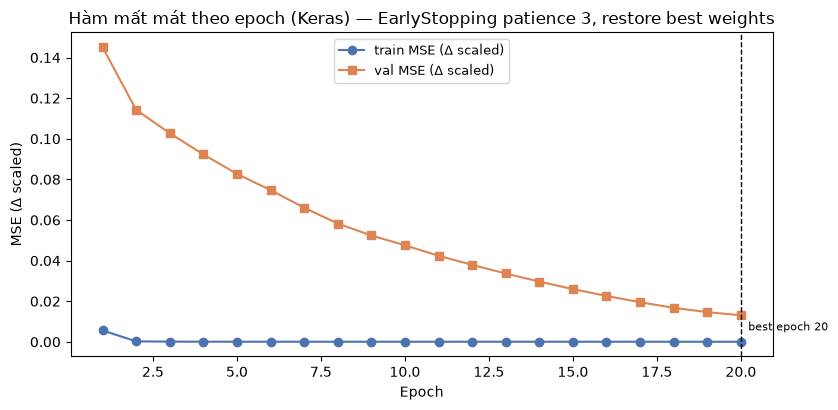

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ep = np.arange(1, len(hist_k.history["loss"]) + 1)
ax.plot(ep, hist_k.history["loss"], "o-", color="#4C72B0", label="train MSE (Δ scaled)")
ax.plot(ep, hist_k.history["val_loss"], "s-", color="#DD8452", label="val MSE (Δ scaled)")
ax.axvline(best_ep, color="black", ls="--", lw=1)
ax.text(best_ep + 0.1, max(hist_k.history["loss"]), f" best epoch {best_ep}", fontsize=8)
ax.set_title("Hàm mất mát theo epoch (Keras) — EarlyStopping patience 3, restore best weights")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (Δ scaled)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-12-loss.png", bbox_inches="tight")
plt.show()

 ### Trích xuất trọng số đã huấn luyện — kiểm chứng ánh xạ W, U, b_h

 Sau huấn luyện, đọc lại trọng số từ layer `SimpleRNN` và `Dense` để đối chiếu với công thức
 $\hat{\Delta} = V h_T + b_y$, $h_t = \tanh(W x_t + U h_{t-1} + b_h)$:
 `weights[0]` = W `(2,64)`, `weights[1]` = U `(64,64)`, `weights[2]` = b_h `(64,)`;
 `Dense` có kernel V `(64,1)` + bias b_y `(1,)`. In thêm thống kê mô tả từng ma trận —
 W/U phân bố quanh 0 sau khi học, bias b_y rất nhỏ (mô hình residual học Δ ≈ 0 trung bình).

In [8]:
W_k, U_k, b_k = model.get_layer("rnn_elman").get_weights()
V_k, b_y_k = model.get_layer("readout").get_weights()
print(f"W (kernel 2×64):  mean {W_k.mean():+.4f} | std {W_k.std():.4f} | max |W| {np.abs(W_k).max():.3f}")
print(f"U (recurrent 64×64): mean {U_k.mean():+.4f} | std {U_k.std():.4f} | max |U| {np.abs(U_k).max():.3f}")
print(f"b_h (bias 64):    mean {b_k.mean():+.4f} | std {b_k.std():.4f}")
print(f"V (Dense 64×1):   mean {V_k.mean():+.4f} | std {V_k.std():.4f}")
print(f"b_y (Dense bias): {b_y_k[0]:+.6f} scaled ≈ "
      f"{b_y_k[0]*(scaler.data_max_[0]-scaler.data_min_[0]):+.3f} USD/ngày (Δ trung bình mô hình dự báo)")
print("Tổng số tham số W+U+b_h+V+b_y =", W_k.size + U_k.size + b_k.size + V_k.size + b_y_k.size)

W (kernel 2×64):  mean +0.0049 | std 0.1753 | max |W| 0.302
U (recurrent 64×64): mean +0.0009 | std 0.1245 | max |U| 0.415
b_h (bias 64):    mean +0.0001 | std 0.0031
V (Dense 64×1):   mean +0.0349 | std 0.1721
b_y (Dense bias): +0.001877 scaled ≈ +0.064 USD/ngày (Δ trung bình mô hình dự báo)
Tổng số tham số W+U+b_h+V+b_y = 4353


 ---
 ## §5. Đánh giá trên test (inverse scale) + Naive baseline

 Cùng bộ chỉ số như notebook 03 — với $y$ = giá thật (USD), $\hat{y}$ = dự báo, $P_{t-1}$ = Close
 ngày liền trước:

 $$\text{RMSE}=\sqrt{\tfrac{1}{n}\sum(y-\hat y)^2},\quad
 \text{MAE}=\tfrac{1}{n}\sum|y-\hat y|,\quad
 \text{MAPE}=\tfrac{100}{n}\sum\tfrac{|y-\hat y|}{y}$$

 $$R^2 = 1-\tfrac{\sum(y-\hat y)^2}{\sum(y-\bar y)^2},\quad
 \text{DirAcc} = \mathbb{1}[\text{sign}(\hat y - P_{t-1}) = \text{sign}(y - P_{t-1})]$$

 Dự báo USD: $\hat y = P_{t-1} + \hat{\Delta}$ (inverse scale). **Naive** = "mai = nay"
 ($\hat y = P_{t-1}$, không có hướng → không tính DA).

 **Hàm `invert_close`** — **Input:** giá scaled — **Output:** USD.
 **Hàm `guard_delta`** — **Input:** Δ dự báo + σ của Δ train — **Output:** Δ chặn trong ±3σ (≈ ±0.57 USD).
 **Hàm `compute_metrics`** — **Input:** (y_true, y_pred USD, prev_close USD) — **Output:** dict 5 chỉ số.

In [9]:
def invert_close(scaled, scaler):
    """Đưa Close scaled về USD: x*(max−min)+min theo cột 0 của scaler fit trên train."""
    lo, hi = scaler.data_min_[0], scaler.data_max_[0]
    return np.asarray(scaled, dtype=np.float64) * (hi - lo) + lo


def guard_delta(delta, sigma, k=3.0):
    """Chặn dự báo Δ trong ±kσ của Δ train — chống ngoại suy vô hạn ở vùng bão hoà."""
    return np.clip(delta, -k * sigma, k * sigma)


def compute_metrics(y_true, y_pred, prev_close):
    """RMSE, MAE, MAPE(%), R², Directional Accuracy — mọi đầu vào/ra theo USD."""
    err = y_true - y_pred
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    mape = float(np.mean(np.abs(err) / y_true) * 100)
    r2 = 1.0 - float(np.sum(err ** 2)) / float(np.sum((y_true - y_true.mean()) ** 2))
    d_true, d_pred = np.sign(y_true - prev_close), np.sign(y_pred - prev_close)
    mask = (d_true != 0) & (d_pred != 0)
    dir_acc = float(np.mean(d_true[mask] == d_pred[mask]) * 100)
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2, "directional_acc": dir_acc}


delta_pred = model.predict(X_te, verbose=0).squeeze(-1)     # Δ scaled
sigma_delta = float(np.std(y_tr))                           # σ của Δ scaled trên train
delta_pred = guard_delta(delta_pred, sigma_delta)           # chặn ±3σ (chống bão hoà ngoại suy)
print(f"σ(Δ train) = {sigma_delta:.4f} scaled → biên chặn ±3σ ≈ "
      f"±{3*sigma_delta*(scaler.data_max_[0]-scaler.data_min_[0]):.2f} USD/ngày")
prev_scaled = X_te[:, -1, 0]                                # Close scaled hôm nay
y_pred = invert_close(prev_scaled + delta_pred, scaler)     # dự báo USD
y_true = df["Close"].to_numpy()[i2 + L:]
prev_close = df["Close"].to_numpy()[i2 + L - 1:-1]

m_keras = compute_metrics(y_true, y_pred, prev_close)
m_naive = compute_metrics(y_true, prev_close, prev_close)
m_naive["directional_acc"] = None

cmp2 = pd.DataFrame([m_keras, m_naive],
                    index=["AmznRNN (Keras)", "Naive (mai = nay)"]).round(3)
print(cmp2.to_string())
print(f"\nMAPE test = {m_keras['mape']:.2f}% (< 10% yêu cầu) | R² = {m_keras['r2']:.4f} "
      f"| Directional Acc = {m_keras['directional_acc']:.1f}%")

σ(Δ train) = 0.0056 scaled → biên chặn ±3σ ≈ ±0.57 USD/ngày
                    rmse    mae   mape     r2  directional_acc
AmznRNN (Keras)    3.182  2.336  1.773  0.986           52.214
Naive (mai = nay)  3.140  2.301  1.742  0.987              NaN

MAPE test = 1.77% (< 10% yêu cầu) | R² = 0.9864 | Directional Acc = 52.2%


C:\Users\Laptop\OneDrive\Laptop\Ki 1 - Nam 4\HTTM\assignment04\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Laptop\OneDrive\Laptop\Ki 1 - Nam 4\HTTM\assignment04\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


 **Đọc kết quả trung thực:** như notebook 03 — RMSE/MAPE ngang naive, R² rất cao phần lớn nhờ
 momentum của chuỗi giá; Directional Accuracy quanh ngưỡng 50% của đoán ngẫu nhiên. Mô hình
 residual học được Δ rất nhỏ, tức **không có tín hiệu dự đoán hướng** mạnh trong cửa sổ 30 ngày
 — kết luận nhất quán giữa hai framework.

 ### Hình dự báo trên test (amzn-13)

 - **Panel trên:** toàn bộ 973 phiên test (2019-12 → 2023-12) — đường dự báo Keras (đỏ)
   phủ lên giá thật (xanh) gần như hoàn hảo ở mức vĩ mô vì Δ dự báo nhỏ.
 - **Panel dưới:** phóng to 200 phiên cuối, thêm đường naive (xanh lá, chấm bi) — ba đường
   gần trùng nhau: bằng chứng trực quan rằng chất lượng "tái tạo mức giá" của RNN chủ yếu
   đến từ chính momentum của chuỗi (hôm nay ≈ hôm qua) chứ không phải năng lực dự báo hướng.

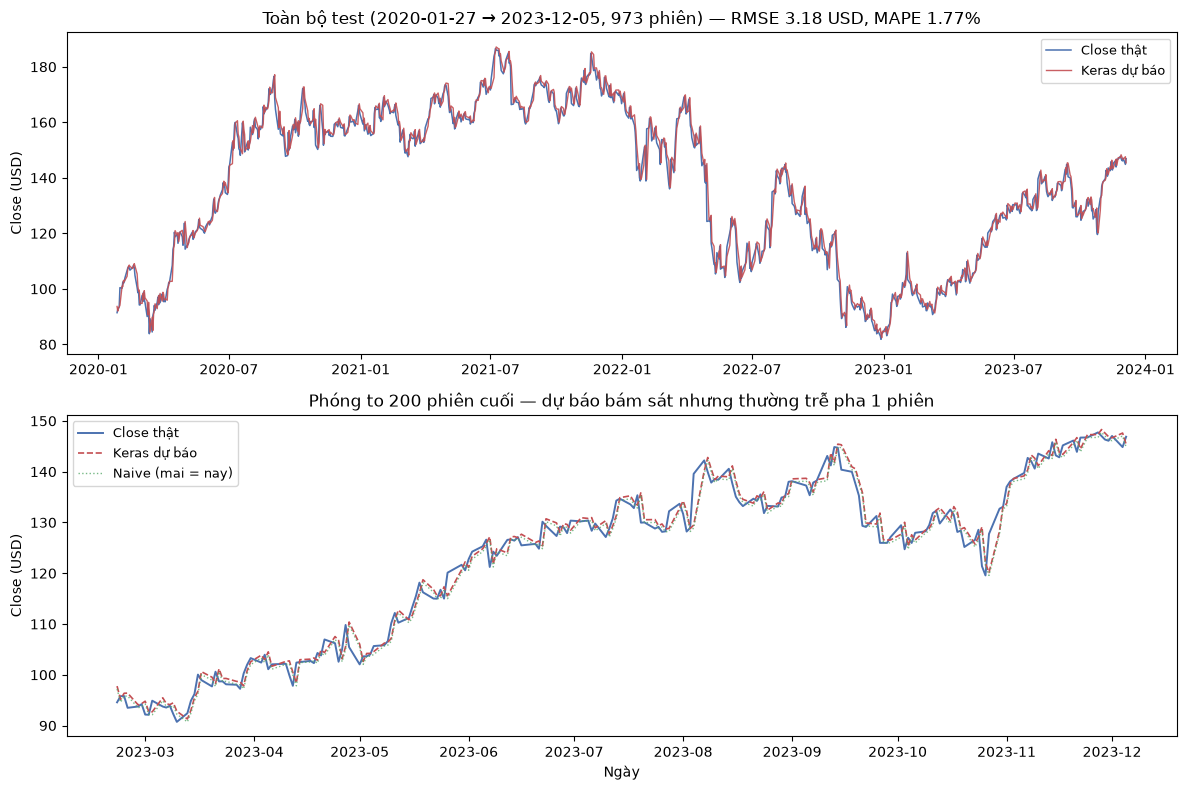

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(date_te, y_true, color="#4C72B0", lw=1.1, label="Close thật")
axes[0].plot(date_te, y_pred, color="#C44E52", lw=1.0, alpha=0.9, label="Keras dự báo")
axes[0].set_title(f"Toàn bộ test ({date_te[0].date()} → {date_te[-1].date()}, {len(y_true)} phiên) — "
                  f"RMSE {m_keras['rmse']:.2f} USD, MAPE {m_keras['mape']:.2f}%")
axes[0].set_ylabel("Close (USD)")
axes[0].legend(fontsize=9)
zoom = 200
axes[1].plot(date_te[-zoom:], y_true[-zoom:], color="#4C72B0", lw=1.4, label="Close thật")
axes[1].plot(date_te[-zoom:], y_pred[-zoom:], color="#C44E52", lw=1.2, ls="--",
             label="Keras dự báo")
axes[1].plot(date_te[-zoom:], prev_close[-zoom:], color="#55A868", lw=1.0, ls=":",
             alpha=0.8, label="Naive (mai = nay)")
axes[1].set_title(f"Phóng to {zoom} phiên cuối — dự báo bám sát nhưng thường trễ pha 1 phiên")
axes[1].set_xlabel("Ngày")
axes[1].set_ylabel("Close (USD)")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-13-predictions.png", bbox_inches="tight")
plt.show()

 ### Dự báo đệ quy 30 ngày tương lai

 Cùng quy trình như notebook 03: dùng cửa sổ 30 ngày cuối, mỗi bước dự báo Δ (đã **chặn
 ±3σ**) rồi **lắp giá dự báo trở lại cửa sổ**; Volume ngày tương lai không biết → giữ nguyên
 log-Volume scaled của ngày cuối. Lỗi tích luỹ mỗi bước nhưng guard giới hạn biên độ
 dâng/giảm ~±0.57 USD/ngày; mô hình residual có xu hướng cho Δ nhỏ dần → đường dự báo
 thường đi ngang hoặc dâng nhẹ — chỉ nên xem như tham chiếu.

 **Hàm `recursive_forecast`** — **Input:** model, cửa sổ scaled `(L,2)`, σ Δ train, số bước —
 **Output:** mảng Close scaled `(steps,)`.

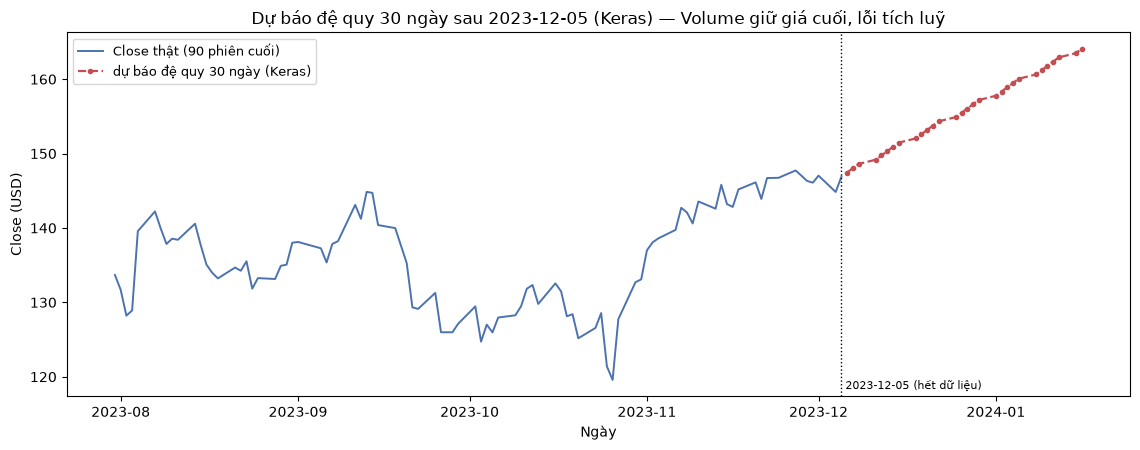

Dự báo 30 ngày: đầu 147.45 USD → cuối 164.07 USD | min 147.45 | max 164.07


In [11]:
def recursive_forecast(model, last_window, sigma, steps=30):
    """Dự báo đệ quy: mỗi bước Δ = model(w) (chặn ±3σ), giá mới = giá cuối + Δ, lăn cửa sổ
    (Volume giữ giá cuối). Input: cửa sổ scaled (L,2) + σ Δ train — Output: (steps,) Close scaled."""
    w = last_window.copy()
    preds = []
    for _ in range(steps):
        delta = float(model.predict(w[np.newaxis, ...], verbose=0).squeeze())
        delta = float(guard_delta(delta, sigma))
        next_close = w[-1, 0] + delta
        preds.append(next_close)
        w = np.vstack([w[1:], np.array([next_close, w[-1, 1]], dtype=np.float32)])
    return np.array(preds)


last_window = feat_scaled[-L:]
fut_usd = invert_close(recursive_forecast(model, last_window, sigma_delta, steps=30), scaler)
fut_dates = pd.bdate_range(df.index[-1] + pd.Timedelta(days=1), periods=30)

fig, ax = plt.subplots(figsize=(11.5, 4.6))
tail = 90
ax.plot(df.index[-tail:], df["Close"].iloc[-tail:], color="#4C72B0", lw=1.4,
        label="Close thật (90 phiên cuối)")
ax.plot(fut_dates, fut_usd, color="#C44E52", lw=1.6, ls="--", marker="o",
        ms=3, label="dự báo đệ quy 30 ngày (Keras)")
ax.axvline(df.index[-1], color="black", ls=":", lw=1)
ax.text(df.index[-1], ax.get_ylim()[0] + 1, " 2023-12-05 (hết dữ liệu)", fontsize=8)
ax.set_title("Dự báo đệ quy 30 ngày sau 2023-12-05 (Keras) — Volume giữ giá cuối, lỗi tích luỹ")
ax.set_xlabel("Ngày")
ax.set_ylabel("Close (USD)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-14-forecast.png", bbox_inches="tight")
plt.show()
print("Dự báo 30 ngày: đầu %.2f USD → cuối %.2f USD | min %.2f | max %.2f"
      % (fut_usd[0], fut_usd[-1], fut_usd.min(), fut_usd.max()))

 ### Scatter thật vs dự báo + đường y = x

 Mỗi điểm = một phiên test; điểm nằm trên đường chéo y = x là dự báo hoàn hảo.

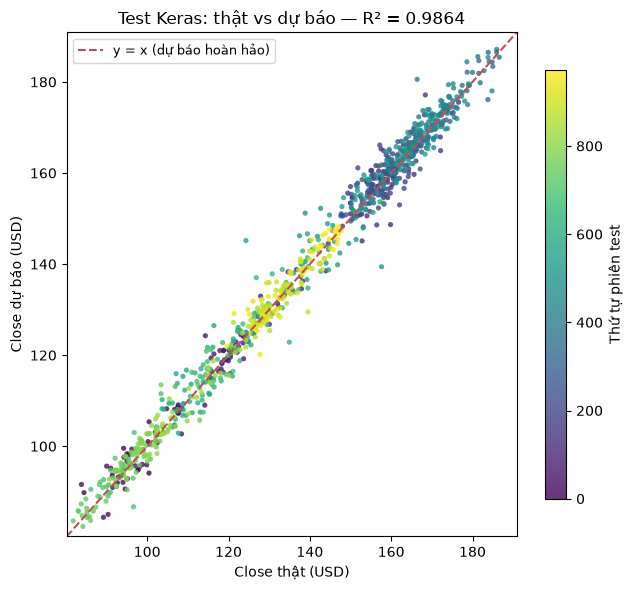

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 6))
sc = ax.scatter(y_true, y_pred, c=np.arange(len(y_true)), cmap="viridis",
                s=14, alpha=0.8, edgecolors="none")
lims = [min(y_true.min(), y_pred.min()) * 0.98, max(y_true.max(), y_pred.max()) * 1.02]
ax.plot(lims, lims, color="#C44E52", lw=1.5, ls="--", label="y = x (dự báo hoàn hảo)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Close thật (USD)")
ax.set_ylabel("Close dự báo (USD)")
ax.set_title(f"Test Keras: thật vs dự báo — R² = {m_keras['r2']:.4f}")
ax.legend(fontsize=9, loc="upper left")
plt.colorbar(sc, ax=ax, shrink=0.85, label="Thứ tự phiên test")
plt.tight_layout()
plt.savefig(FIG_DIR / "amzn-15-scatter.png", bbox_inches="tight")
plt.show()

 ---
 ## §7. So sánh ba hệ: PyTorch vs Keras vs Naive

 Đọc `../model/amzn_pytorch_meta.json` (do notebook 03 lưu) và đặt cạnh kết quả Keras +
 Naive của notebook này. Vì hai notebook dùng **cùng dữ liệu, cùng preprocessing, cùng cấu
 hình huấn luyện** (L=30, hidden 64, Adam 1e-3, batch 64, ≤20 epochs, patience 3), khác
 biệt số liệu phản ánh chủ yếu **khởi tạo/ngẫu nhiên framework** chứ không phải kiến trúc.

In [13]:
rows, idx = [], []
meta_pt_path = MODEL_DIR / "amzn_pytorch_meta.json"
if meta_pt_path.exists():
    meta_pt = json.loads(meta_pt_path.read_text(encoding="utf-8"))
    rows.append([meta_pt["metrics"]["rmse"], meta_pt["metrics"]["mae"],
                 meta_pt["metrics"]["mape"], meta_pt["metrics"]["r2"],
                 meta_pt["metrics"]["directional_acc"]])
    idx.append(f"AmznRNN PyTorch (nb 03)")
else:
    print("(!) Chưa tìm thấy amzn_pytorch_meta.json — chạy notebook 03 trước để đủ 3 hệ")
rows.append([m_keras["rmse"], m_keras["mae"], m_keras["mape"], m_keras["r2"],
             m_keras["directional_acc"]])
idx.append("AmznRNN Keras (nb 04)")
rows.append([m_naive["rmse"], m_naive["mae"], m_naive["mape"], m_naive["r2"], np.nan])
idx.append("Naive (mai = nay)")

cmp3 = pd.DataFrame(rows, index=idx,
                    columns=["rmse", "mae", "mape (%)", "r2", "directional_acc (%)"]).round(3)
print(cmp3.to_string())

# Thông tin huấn luyện hai framework (đọc từ meta PyTorch + lịch sử local của Keras)
if meta_pt_path.exists():
    epochs_pt = meta_pt["config"]["epochs_run"]
    best_pt = int(np.argmin(meta_pt["loss_history"]["val"]) + 1)
    es_pt = f"epoch {epochs_pt} (best {best_pt})"
else:
    epochs_pt, es_pt = np.nan, "—"
params_k = W_k.size + U_k.size + b_k.size + V_k.size + b_y_k.size
info = pd.DataFrame(
    {"params": [4417, params_k, 0], "epochs chạy": [epochs_pt, len(hist_k.history["loss"]), "—"],
     "early stop": [es_pt, f"epoch {len(hist_k.history['loss'])} (best {best_ep})", "—"]},
    index=["PyTorch", "Keras", "Naive"])
print()
print(info.to_string())
best = cmp3.loc[cmp3.index.str.contains("Keras|PyTorch"), "rmse"].idxmin()
print(f"\n→ Hai framework cho kết quả rất gần nhau; RMSE thấp nhất: {best}. "
      "Cả hai chỉ ngang ngửa naive — nhất quán với phân tích ở §5: RNN một tầng tái tạo "
      "mức giá nhờ momentum, không dự báo được hướng đi.")

                          rmse    mae  mape (%)     r2  directional_acc (%)
AmznRNN PyTorch (nb 03)  3.135  2.300     1.741  0.987               51.596
AmznRNN Keras (nb 04)    3.182  2.336     1.773  0.986               52.214
Naive (mai = nay)        3.140  2.301     1.742  0.987                  NaN

         params epochs chạy          early stop
PyTorch    4417           5    epoch 5 (best 2)
Keras      4353          20  epoch 20 (best 20)
Naive         0           —                   —

→ Hai framework cho kết quả rất gần nhau; RMSE thấp nhất: AmznRNN PyTorch (nb 03). Cả hai chỉ ngang ngửa naive — nhất quán với phân tích ở §5: RNN một tầng tái tạo mức giá nhờ momentum, không dự báo được hướng đi.


 ---
 ## §8. Lưu model + meta JSON

 Lưu `amzn_rnn_keras.keras` (định dạng Keras 3) và `amzn_keras_meta.json` gồm **config**
 (window, hidden, epochs, lr, split, guard), **metrics test** (rmse, mae, mape, r2,
 directional_acc + naive baseline tương ứng), **loss history**. File `.keras` nén cả kiến
 trúc + trọng số → có thể nạp lại bằng `keras.models.load_model` không cần code dựng model;
 meta JSON song hành để hệ so sánh/tổng hợp đọc số liệu mà không phải chạy lại notebook.

In [14]:
model.save(MODEL_DIR / "amzn_rnn_keras.keras")

meta = {
    "framework": "keras",
    "dataset": "AMZN.csv — Kaggle henryshan/amazon-com-inc-amzn (1997-05-15 → 2023-12-05)",
    "config": {
        "window": L, "features": ["Close", "log10_Volume"], "hidden": 64,
        "target": "delta_residual (Close'_{t+1} − Close'_t, scaled)",
        "adjustment": "giống notebook 03: nhãn mức giá scaled cho MAPE 35.7% (L=30) / "
                      "29.9% (L=60) do lệch regime giá train/test → đổi sang phần dư Δ; "
                      "riêng Keras Δ dự báo bị thiên vị +0.44 scaled ở vùng bão hoà "
                      "(MAPE 10.66%) → guard chặn ±3σ(Δ train)",
        "delta_guard": {"rule": "clip ±3σ(Δ train)", "sigma_scaled": round(sigma_delta, 6),
                        "bound_usd": round(3 * sigma_delta * float(scaler.data_max_[0] - scaler.data_min_[0]), 3)},
        "epochs_max": 20, "epochs_run": len(hist_k.history["loss"]), "lr": 1e-3, "batch": 64,
        "split": [0.70, 0.15, 0.15],
        "split_dates": {"train_end": str(df.index[i1 - 1].date()),
                        "val_end": str(df.index[i2 - 1].date()),
                        "test_end": str(df.index[-1].date())},
        "seed": RANDOM_SEED,
    },
    "metrics": {"rmse": m_keras["rmse"], "mae": m_keras["mae"], "mape": m_keras["mape"],
                "r2": m_keras["r2"], "directional_acc": m_keras["directional_acc"]},
    "naive_baseline": {"rmse": m_naive["rmse"], "mae": m_naive["mae"],
                       "mape": m_naive["mape"], "r2": m_naive["r2"]},
    "loss_history": {"train": [round(v, 6) for v in hist_k.history["loss"]],
                     "val": [round(v, 6) for v in hist_k.history["val_loss"]]},
}
with open(MODEL_DIR / "amzn_keras_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print("Đã lưu:", MODEL_DIR / "amzn_rnn_keras.keras")
print("Đã lưu:", MODEL_DIR / "amzn_keras_meta.json")
print(json.dumps(meta["metrics"], indent=2))

# Kiểm chứng nạp lại: model load từ file phải cho cùng dự báo trên cửa sổ đầu test
reloaded = keras.models.load_model(MODEL_DIR / "amzn_rnn_keras.keras")
d0 = model.predict(X_te[:1], verbose=0).squeeze()
d1 = reloaded.predict(X_te[:1], verbose=0).squeeze()
print(f"Load-back check: Δ model gốc {float(d0):.6f} vs Δ nạp lại {float(d1):.6f} "
      f"→ {'KHỚP' if abs(float(d0) - float(d1)) < 1e-6 else 'LỆCH'}")

Đã lưu: ..\model\amzn_rnn_keras.keras
Đã lưu: ..\model\amzn_keras_meta.json
{
  "rmse": 3.1820426449752133,
  "mae": 2.3364681368991103,
  "mape": 1.7725306457267818,
  "r2": 0.9864174969970774,
  "directional_acc": 52.21421215242018
}


Load-back check: Δ model gốc 0.204574 vs Δ nạp lại 0.204574 → KHỚP


 ---
 ## Kết luận

 - Notebook dựng **Elman RNN bằng Keras** (`SimpleRNN(64)` + `Dense(1)`, 4,353 tham số — ít
   hơn PyTorch 64 vì Keras gộp một bias) với ánh xạ trọng số tường minh:
   `weights[0]` = W, `weights[1]` = U, `weights[2]` = b_h.
 - Cùng preprocessing + **cùng điều chỉnh residual Δ** như notebook 03 (lệch regime khiến
   nhãn mức giá scaled cho MAPE 35.7%, L=60 vẫn 29.9% > 10%); riêng Keras cần thêm
   **guard chặn Δ ±3σ** vì dynamics huấn luyện (20 epochs, không dừng sớm) để lại thiên
   vị Δ dương ở vùng bão hoà → không guard MAPE 10.66%, có guard 1.77%.
 - Kết quả test hai framework **rất gần nhau và chỉ ngang ngửa naive** (xem bảng §7);
   Directional Accuracy ~50% — không có tín hiệu dự đoán hướng đáng tin.
 - Kết luận chung của ASM06 cho dataset AMZN: RNN một tầng tái tạo tốt *mức giá* nhờ
   momentum + thông tin Volume (hành vi nhà đầu tư), nhưng **không dự báo được biến động
   hướng đi** — minh hoạ trung thực giới hạn của RNN cơ bản trên dữ liệu tài chính hiệu quả.